In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

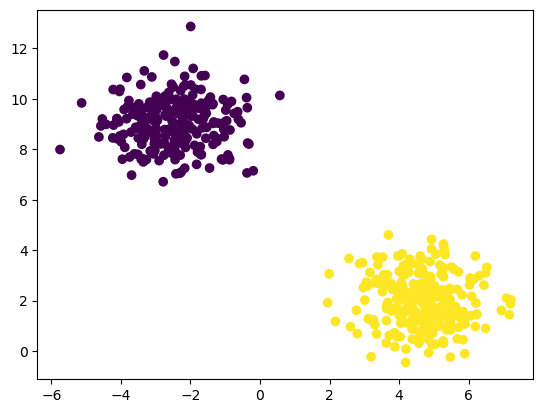

In [2]:
x,y = make_blobs(n_samples= 500, n_features=2, centers=2, random_state=42)
plt.scatter(x[:,0],x[:,1],c=y)

In [3]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [4]:
Scaler = StandardScaler()
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.fit_transform(x_test)

In [8]:
model = keras.Sequential([layers.Dense(12,activation='sigmoid',input_shape =(2,)),
                         layers.Dense(6,activation='sigmoid',input_shape =(2,)),
                         layers.Dense(4,activation='sigmoid',input_shape =(2,)),
                         layers.Dense(2,activation='sigmoid',input_shape =(2,)),
                         layers.Dense(1,activation='sigmoid',input_shape =(2,))])

In [9]:
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])

In [7]:
history = model.fit(x_train,y_train, epochs=50, batch_size = 8, verbose = 1, validation_data=(x_test,y_test))

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.2644 - val_accuracy: 1.0000 - val_loss: 0.2423
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.2269 - val_accuracy: 1.0000 - val_loss: 0.2100
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1984 - val_accuracy: 1.0000 - val_loss: 0.1851
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1760 - val_accuracy: 1.0000 - val_loss: 0.1652
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1581 - val_accuracy: 1.0000 - val_loss: 0.1492
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1435 - val_accuracy: 1.0000 - val_loss: 0.1359
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1313 - val_accuracy: 1.0000 - val_loss: 0.1248
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1210 - val_accuracy: 1.0000 - val_loss:

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')

In [4]:
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [5]:
df.shape

(1300, 6)

In [10]:
df['alert'].unique()

array(['green', 'yellow', 'orange', 'red'], dtype=object)

In [13]:
x = df.iloc[:,0:-1]
y = np.array(df.iloc[:,-1]).reshape(-1,1)

In [14]:
y

array([['green'],
       ['green'],
       ['green'],
       ...,
       ['yellow'],
       ['yellow'],
       ['yellow']], dtype=object)

In [11]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

In [16]:
y_encoded

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y_encoded,test_size=0.25,random_state=42)

In [18]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
classifier = Sequential([
                        Dense(5,activation='relu'),
                        Dense(128,activation='relu'),
                        Dropout(0.3),
                        Dense(64,activation='relu'),
                        Dropout(0.2),
                        Dense(16,activation='relu'),
                        Dropout(0.1),
                        Dense(4,activation='softmax')])

In [21]:
classifier.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

# 'Early Stopping'

In [23]:
earlystopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [30]:
history = classifier.fit(x_train,y_train, 
                         epochs=100,
                         batch_size = 10,
                         validation_data=(x_test,y_test),
                         verbose = 1,
                        callbacks = earlystopping)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.4182 - val_accuracy: 0.8554 - val_loss: 0.4983
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8513 - loss: 0.4226 - val_accuracy: 0.8585 - val_loss: 0.4949
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8564 - loss: 0.4192 - val_accuracy: 0.8523 - val_loss: 0.4877
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8585 - loss: 0.4192 - val_accuracy: 0.8523 - val_loss: 0.4859
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8523 - loss: 0.4190 - val_accuracy: 0.8492 - val_loss: 0.4915
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8544 - loss: 0.4199 - val_accuracy: 0.8462 - val_loss: 0.5055
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8462 - loss: 0.4243 - val_accuracy: 0.8554 - val_loss: 0.4851
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8503 - loss: 0.4167 - val_accuracy: 0.8554 - v

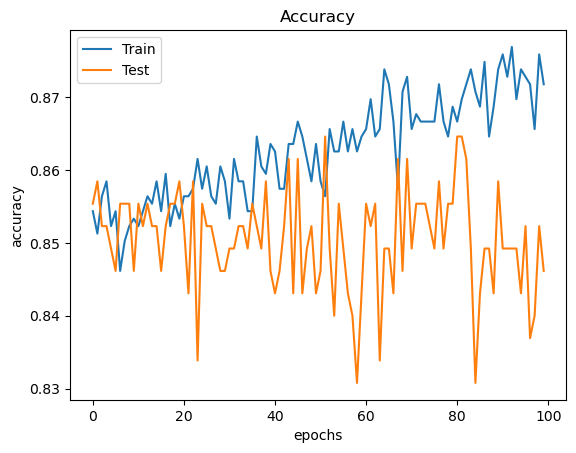

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['Train','Test'])

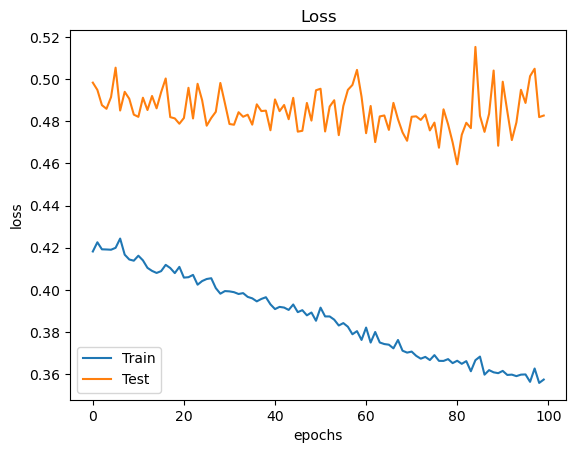

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['Train','Test'])